# Chest X-Ray Multi-Label Disease Classification — 4-Model Architecture Comparison

**ICT 4442 — Deep Learning Mini Project**

Compares four architectures spanning distinct families on the CheXpert dataset:
- **MLP** (classical baseline, image-only)
- **ResNet18** (CNN)
- **CNN-LSTM** (RNN/LSTM — patch-sequence)
- **ViT-B/16** (attention-based)

All four are trained under an identical protocol: same train/val/test split, same
preprocessing, same loss (multi-label BCE), same evaluation metrics (per-disease
AUC-ROC, precision, recall, F1). This is a **multi-label** problem (5 independent
binary diseases per image), not multi-class — a patient can have multiple
conditions simultaneously, so BCEWithLogitsLoss + sigmoid is used throughout,
not CrossEntropyLoss + softmax.


## 1. Imports and Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights, vit_b_16, ViT_B_16_Weights
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    precision_recall_fscore_support, confusion_matrix
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda


## 2. Configuration

In [2]:
DATASET_ROOT = r'D:\Datasets\CheXpert-v1.0-small'
OUTPUT_DIR   = r'D:\Projects\ChestXray-Academic-Comparison\outputs'
CHECKPOINT_DIR = r'D:\Projects\ChestXray-Academic-Comparison\checkpoints'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

DISEASE_COLS = [
    'Atelectasis',
    'Cardiomegaly',
    'Consolidation',
    'Edema',
    'Pleural Effusion'
]

U_ONES  = ['Atelectasis', 'Edema']            # uncertain (-1) -> treated as positive (1)
U_ZEROS = ['Cardiomegaly', 'Consolidation', 'Pleural Effusion']  # uncertain (-1) -> treated as negative (0)

IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_WORKERS = 0
NUM_EPOCHS  = 5   # reduce for a quicker first pass; 15-20 for final results

print(f"Dataset root: {DATASET_ROOT}")
print(f"Diseases ({len(DISEASE_COLS)}): {DISEASE_COLS}")

Dataset root: D:\Datasets\CheXpert-v1.0-small
Diseases (5): ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']


## 3. Data Loading and Cleaning

CheXpert labels are `1` (positive), `0` (negative), `-1` (uncertain), or blank
(not mentioned). We apply the standard "U-Ones/U-Zeros" policy: uncertain labels
for diseases where uncertainty tends to reflect real subtle findings
(Atelectasis, Edema) are mapped to positive; uncertain labels for diseases where
it more often reflects genuine ambiguity (Cardiomegaly, Consolidation, Pleural
Effusion) are mapped to negative. Blank/NaN (not mentioned) is treated as negative.


In [3]:
def load_and_clean_csv(csv_path, dataset_root):
    df = pd.read_csv(csv_path)

    # Frontal-view images only (lateral views excluded for consistency)
    df = df[df['Frontal/Lateral'] == 'Frontal'].reset_index(drop=True)

    # Fix image paths to point at the actual local dataset location
    df['Path'] = df['Path'].apply(
        lambda x: os.path.join(dataset_root, x.replace('CheXpert-v1.0-small/', ''))
    )

    # Not-mentioned (NaN) -> negative
    df[DISEASE_COLS] = df[DISEASE_COLS].fillna(0)

    # Uncertain (-1) label policy
    for col in U_ONES:
        df[col] = df[col].replace(-1, 1)
    for col in U_ZEROS:
        df[col] = df[col].replace(-1, 0)

    return df


csv_path = os.path.join(DATASET_ROOT, 'train.csv')
full_df = load_and_clean_csv(csv_path, DATASET_ROOT)
print(f"Total frontal-view images: {len(full_df)}")
full_df[DISEASE_COLS].sum()

Total frontal-view images: 191027


Atelectasis         59583.0
Cardiomegaly        23385.0
Consolidation       12983.0
Edema               61493.0
Pleural Effusion    76899.0
dtype: float64

## 4. Train / Validation / Test Split

CheXpert's official `valid.csv` is a tiny (~200-image) leaderboard-style set,
not suited for real model selection or a held-out test set. Instead, we split
`train.csv` itself into **train (80%) / validation (10%) / test (10%)**, fixed
with `random_state=42` and reused identically for all four models — this is
what makes the cross-model comparison valid.


In [4]:
# First split off the test set (10%), then split remaining 90% into train/val
train_val_df, test_df = train_test_split(
    full_df, test_size=0.10, random_state=SEED,
    stratify=full_df['Pleural Effusion'].astype(int)
)

train_df, val_df = train_test_split(
    train_val_df, test_size=(0.10 / 0.90), random_state=SEED,  # 10% of original total
    stratify=train_val_df['Pleural Effusion'].astype(int)
)

print(f"Train: {len(train_df)}  ({len(train_df)/len(full_df)*100:.1f}%)")
print(f"Val:   {len(val_df)}  ({len(val_df)/len(full_df)*100:.1f}%)")
print(f"Test:  {len(test_df)}  ({len(test_df)/len(full_df)*100:.1f}%)")

# Save the splits so every model (and every team member) uses the exact
# same rows, even if this notebook is re-run on a different machine.
train_df.to_csv(os.path.join(OUTPUT_DIR, 'train_split.csv'), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, 'val_split.csv'), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, 'test_split.csv'), index=False)

Train: 152821  (80.0%)
Val:   19103  (10.0%)
Test:  19103  (10.0%)


## 5. Dataset Class and Preprocessing Pipeline

In [5]:
def get_transforms(mode='train'):
    if mode == 'train':
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.15, contrast=0.15),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])


class CheXpertDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['Path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        labels = torch.tensor(row[DISEASE_COLS].values.astype(np.float32), dtype=torch.float32)
        return img, labels


train_ds = CheXpertDataset(train_df, transform=get_transforms('train'))
val_ds   = CheXpertDataset(val_df,   transform=get_transforms('val'))
test_ds  = CheXpertDataset(test_df,  transform=get_transforms('val'))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("DataLoaders ready.")

DataLoaders ready.


## 6. Class Weights (for imbalanced multi-label BCE loss)

In [6]:
def get_class_weights(df, device):
    weights = []
    for col in DISEASE_COLS:
        pos = (df[col] == 1).sum()
        neg = (df[col] == 0).sum()
        weight = neg / (pos + 1e-6)
        weights.append(weight)
        print(f"{col:20s} pos={pos:6d}  neg={neg:6d}  weight={weight:.2f}")
    return torch.tensor(weights, dtype=torch.float32).to(device)

pos_weights = get_class_weights(train_df, device)

Atelectasis          pos= 47657  neg=105164  weight=2.21
Cardiomegaly         pos= 18759  neg=134062  weight=7.15
Consolidation        pos= 10436  neg=142385  weight=13.64
Edema                pos= 49292  neg=103529  weight=2.10
Pleural Effusion     pos= 61519  neg= 91302  weight=1.48


## 7. Model Architectures (4 families)

All four output 5 raw logits (one per disease) — no final activation, since
`BCEWithLogitsLoss` applies sigmoid internally for numerical stability.


In [7]:
# --- Model 1: MLP (Classical baseline) ---
class MLPBaseline(nn.Module):
    def __init__(self, num_classes=5, img_size=224, dropout=0.3):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(3*img_size*img_size, 512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(self.flatten(x))


# --- Model 2: ResNet18 (CNN) ---
def get_resnet18(num_classes=5, dropout=0.3):
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))
    return model


# --- Model 3: CNN-LSTM (RNN/LSTM — patch sequence) ---
class CNNLSTM(nn.Module):
    def __init__(self, num_classes=5, patch_size=32, img_size=224, hidden_size=128):
        super().__init__()
        assert img_size % patch_size == 0
        self.patch_size = patch_size
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.lstm = nn.LSTM(input_size=32, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        B = x.size(0)
        p = self.patch_size
        patches = x.unfold(2, p, p).unfold(3, p, p)
        patches = patches.contiguous().view(B, 3, -1, p, p).permute(0, 2, 1, 3, 4)
        N = patches.size(1)
        feats = [self.cnn(patches[:, i]).view(B, -1) for i in range(N)]
        seq = torch.stack(feats, dim=1)
        _, (h_n, _) = self.lstm(seq)
        return self.fc(h_n[-1])


# --- Model 4: ViT-B/16 (Attention-based) ---
def get_vit(num_classes=5, dropout=0.3):
    model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))
    return model


print("MLP params:     ", sum(p.numel() for p in MLPBaseline().parameters()))
print("ResNet18 params:", sum(p.numel() for p in get_resnet18().parameters()))
print("CNN-LSTM params:", sum(p.numel() for p in CNNLSTM().parameters()))
print("ViT params:     ", sum(p.numel() for p in get_vit().parameters()))

MLP params:      77137157
ResNet18 params: 11179077
CNN-LSTM params: 88677
ViT params:      85802501


## 8. Sanity-Check CNN-LSTM Patch Logic (before committing to a full training run)

In [8]:
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
test_model = CNNLSTM()
out = test_model(dummy)
print(f"CNN-LSTM output shape: {out.shape}  (expected: [2, {len(DISEASE_COLS)}])")

CNN-LSTM output shape: torch.Size([2, 5])  (expected: [2, 5])


## 9. Shared Training and Evaluation Functions

Multi-label setup throughout: `BCEWithLogitsLoss` (with class weights), sigmoid
for probabilities, per-disease AUC-ROC as the primary metric.


In [9]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = 0
    all_labels, all_preds = [], []

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        if device.type == 'cuda':
            with torch.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        all_labels.append(labels.cpu().detach().numpy())
        all_preds.append(torch.sigmoid(outputs).cpu().detach().numpy())

    all_labels = np.concatenate(all_labels)
    all_preds  = np.concatenate(all_preds)
    avg_loss   = total_loss / len(loader)
    aucs = _per_disease_auc(all_labels, all_preds)
    return avg_loss, float(np.mean(aucs))


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluating', leave=False):
            images, labels = images.to(device), labels.to(device)
            if device.type == 'cuda':
                with torch.autocast(device_type='cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)

            total_loss += loss.item()
            all_labels.append(labels.cpu().numpy())
            all_preds.append(torch.sigmoid(outputs).cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_preds  = np.concatenate(all_preds)
    avg_loss   = total_loss / len(loader)
    aucs = _per_disease_auc(all_labels, all_preds)
    return avg_loss, float(np.mean(aucs)), all_labels, all_preds


def _per_disease_auc(labels, preds):
    aucs = []
    for i in range(labels.shape[1]):
        try:
            aucs.append(roc_auc_score(labels[:, i], preds[:, i]))
        except Exception:
            aucs.append(0.0)
    return aucs


def train_model(model, model_name, epochs=NUM_EPOCHS, lr=1e-4, freeze_schedule=False):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler = torch.amp.GradScaler(device='cuda') if device.type == 'cuda' else None

    history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}
    best_auc = 0.0

    for epoch in range(1, epochs + 1):
        if freeze_schedule and hasattr(model, 'backbone'):
            if epoch == 1:
                print(f"[{model_name}] Epochs 1-2: backbone frozen")
                for p in model.backbone.parameters():
                    p.requires_grad = False
            if epoch == 3:
                print(f"[{model_name}] Epoch 3+: full model unfrozen")
                for p in model.backbone.parameters():
                    p.requires_grad = True

        train_loss, train_auc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_auc'].append(train_auc)
        history['val_auc'].append(val_auc)

        print(f"[{model_name}] Epoch {epoch}/{epochs}  Train Loss: {train_loss:.4f}  Train AUC: {train_auc:.4f}  "
              f"Val Loss: {val_loss:.4f}  Val AUC: {val_auc:.4f}")

        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, f'{model_name}_best.pth'))

    # reload best checkpoint before returning
    model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, f'{model_name}_best.pth')))
    return model, history

## 10. Train Model 1 — MLP Baseline

In [10]:
mlp_model = MLPBaseline(num_classes=len(DISEASE_COLS), img_size=IMG_SIZE)
mlp_model, mlp_history = train_model(mlp_model, 'mlp', freeze_schedule=False)

[mlp] Epoch 1/5  Train Loss: 1.0514  Train AUC: 0.5898  Val Loss: 1.0146  Val AUC: 0.6314


[mlp] Epoch 2/5  Train Loss: 1.0139  Train AUC: 0.6183  Val Loss: 0.9987  Val AUC: 0.6415


[mlp] Epoch 3/5  Train Loss: 1.0042  Train AUC: 0.6284  Val Loss: 0.9861  Val AUC: 0.6498


[mlp] Epoch 4/5  Train Loss: 0.9959  Train AUC: 0.6376  Val Loss: 0.9826  Val AUC: 0.6556


[mlp] Epoch 5/5  Train Loss: 0.9897  Train AUC: 0.6449  Val Loss: 0.9796  Val AUC: 0.6606


C:\Users\gujar\AppData\Local\Temp\ipykernel_40312\3276740800.py:109: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(CHECKPOINT_D

In [11]:
import json
with open(os.path.join(OUTPUT_DIR, 'mlp_history.json'), 'w') as f:
    json.dump(mlp_history, f)

In [12]:
import os
print(os.listdir(OUTPUT_DIR))

['mlp_history.json', 'test_split.csv', 'train_split.csv', 'val_split.csv']


In [14]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

MLP Test Mean AUC: 0.6608


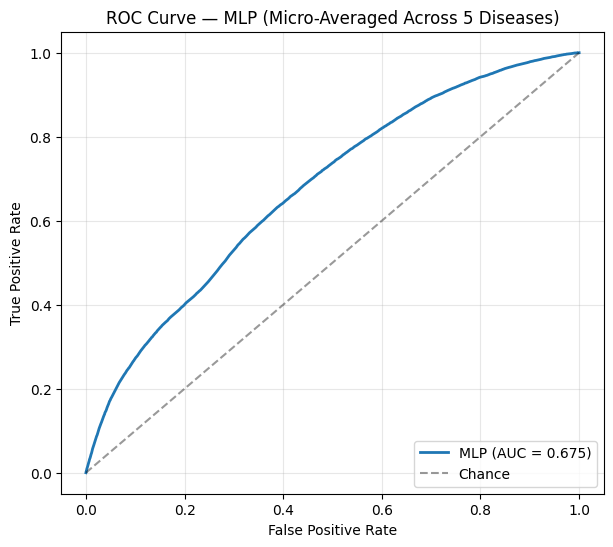

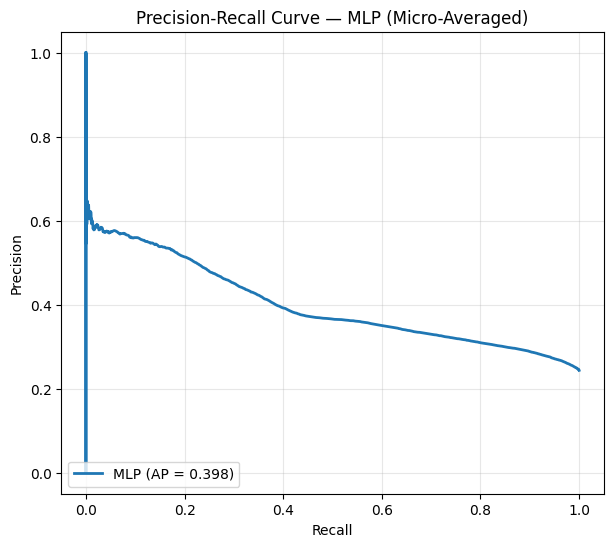

In [15]:
# Get MLP's predictions on the test set
_, mlp_test_auc, mlp_test_labels, mlp_test_preds = evaluate(mlp_model, test_loader, criterion)
print(f"MLP Test Mean AUC: {mlp_test_auc:.4f}")

# ROC curve (micro-averaged across all 5 diseases)
fpr, tpr, _ = roc_curve(mlp_test_labels.ravel(), mlp_test_preds.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'MLP (AUC = {roc_auc:.3f})', color='tab:blue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — MLP (Micro-Averaged Across 5 Diseases)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(mlp_test_labels.ravel(), mlp_test_preds.ravel())
ap = average_precision_score(mlp_test_labels, mlp_test_preds, average='micro')

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f'MLP (AP = {ap:.3f})', color='tab:blue', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — MLP (Micro-Averaged)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

In [16]:
import seaborn as sns

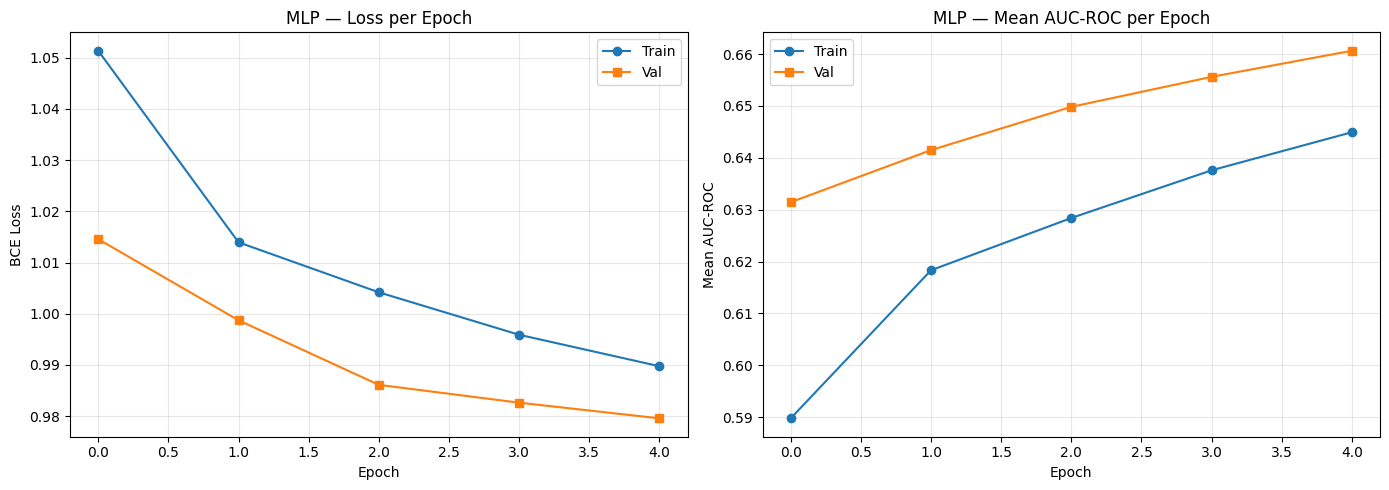

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mlp_history['train_loss'], marker='o', label='Train')
axes[0].plot(mlp_history['val_loss'], marker='s', label='Val')
axes[0].set_title('MLP — Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(mlp_history['train_auc'], marker='o', label='Train')
axes[1].plot(mlp_history['val_auc'], marker='s', label='Val')
axes[1].set_title('MLP — Mean AUC-ROC per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean AUC-ROC')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mlp_loss_auc_curves.png'), dpi=150)
plt.show()

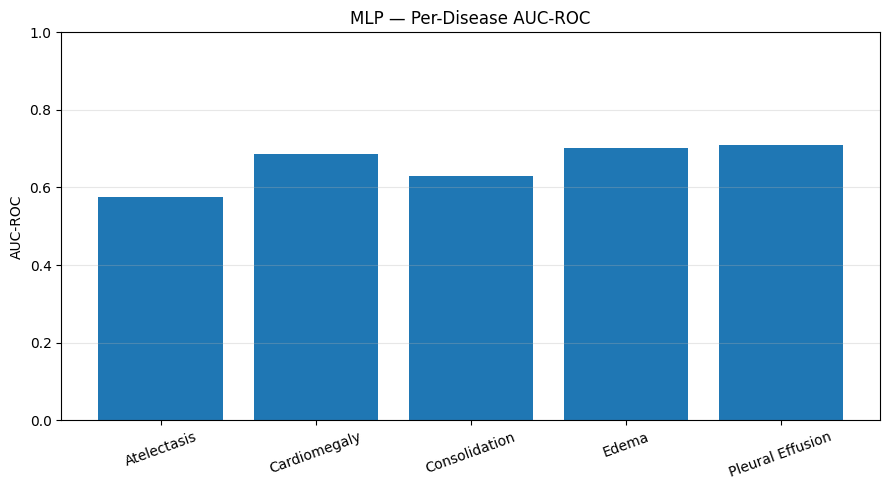

Atelectasis         : 0.5752
Cardiomegaly        : 0.6872
Consolidation       : 0.6291
Edema               : 0.7025
Pleural Effusion    : 0.7100


In [18]:
def _per_disease_auc(labels, preds):
    aucs = []
    for i in range(labels.shape[1]):
        try:
            aucs.append(roc_auc_score(labels[:, i], preds[:, i]))
        except Exception:
            aucs.append(0.0)
    return aucs

mlp_per_disease = _per_disease_auc(mlp_test_labels, mlp_test_preds)

plt.figure(figsize=(9, 5))
plt.bar(DISEASE_COLS, mlp_per_disease, color='tab:blue')
plt.ylabel('AUC-ROC'); plt.ylim(0, 1.0)
plt.title('MLP — Per-Disease AUC-ROC')
plt.xticks(rotation=20)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mlp_per_disease_auc.png'), dpi=150)
plt.show()

for d, a in zip(DISEASE_COLS, mlp_per_disease):
    print(f"{d:20s}: {a:.4f}")

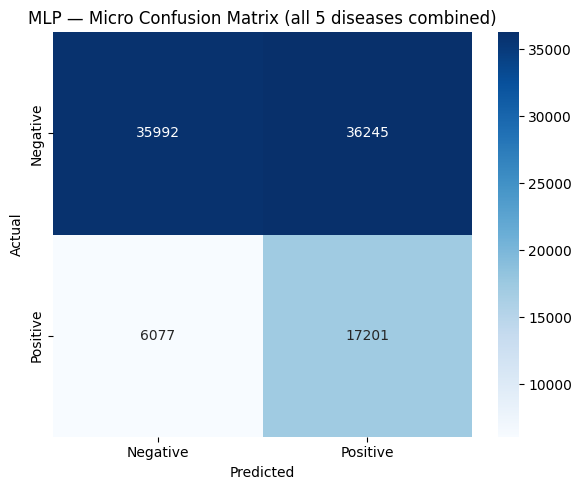

In [19]:
mlp_binary_preds = (mlp_test_preds >= 0.5).astype(int)
mlp_cm = confusion_matrix(mlp_test_labels.ravel(), mlp_binary_preds.ravel())

plt.figure(figsize=(6, 5))
sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('MLP — Micro Confusion Matrix (all 5 diseases combined)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mlp_confusion_matrix.png'), dpi=150)
plt.show()

## 11. Train Model 2 — ResNet18

In [20]:
class ResNet18Wrapper(nn.Module):
    """Thin wrapper so train_model's freeze_schedule logic (which looks for
    .backbone) works uniformly across models."""
    def __init__(self, num_classes=5, dropout=0.3):
        super().__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))

    def forward(self, x):
        return self.classifier(self.backbone(x))

resnet_model = ResNet18Wrapper(num_classes=len(DISEASE_COLS))
resnet_model, resnet_history = train_model(resnet_model, 'resnet18', freeze_schedule=True)

[resnet18] Epochs 1-2: backbone frozen


[resnet18] Epoch 1/5  Train Loss: 1.0206  Train AUC: 0.6092  Val Loss: 0.9710  Val AUC: 0.6706


[resnet18] Epoch 2/5  Train Loss: 0.9939  Train AUC: 0.6438  Val Loss: 0.9684  Val AUC: 0.6777
[resnet18] Epoch 3+: full model unfrozen


[resnet18] Epoch 3/5  Train Loss: 0.8753  Train AUC: 0.7549  Val Loss: 0.8390  Val AUC: 0.7860


[resnet18] Epoch 4/5  Train Loss: 0.8293  Train AUC: 0.7836  Val Loss: 0.8056  Val AUC: 0.7972


C:\Users\gujar\AppData\Local\Temp\ipykernel_40312\3276740800.py:109: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(CHECKPOINT_D

[resnet18] Epoch 5/5  Train Loss: 0.8044  Train AUC: 0.7984  Val Loss: 0.7946  Val AUC: 0.8034


In [21]:
with open(os.path.join(OUTPUT_DIR, 'resnet18_history.json'), 'w') as f:
    json.dump(resnet_history, f)

In [22]:
_, resnet_test_auc, resnet_test_labels, resnet_test_preds = evaluate(resnet_model, test_loader, criterion)
print(f"ResNet18 Test Mean AUC: {resnet_test_auc:.4f}")

ResNet18 Test Mean AUC: 0.8043


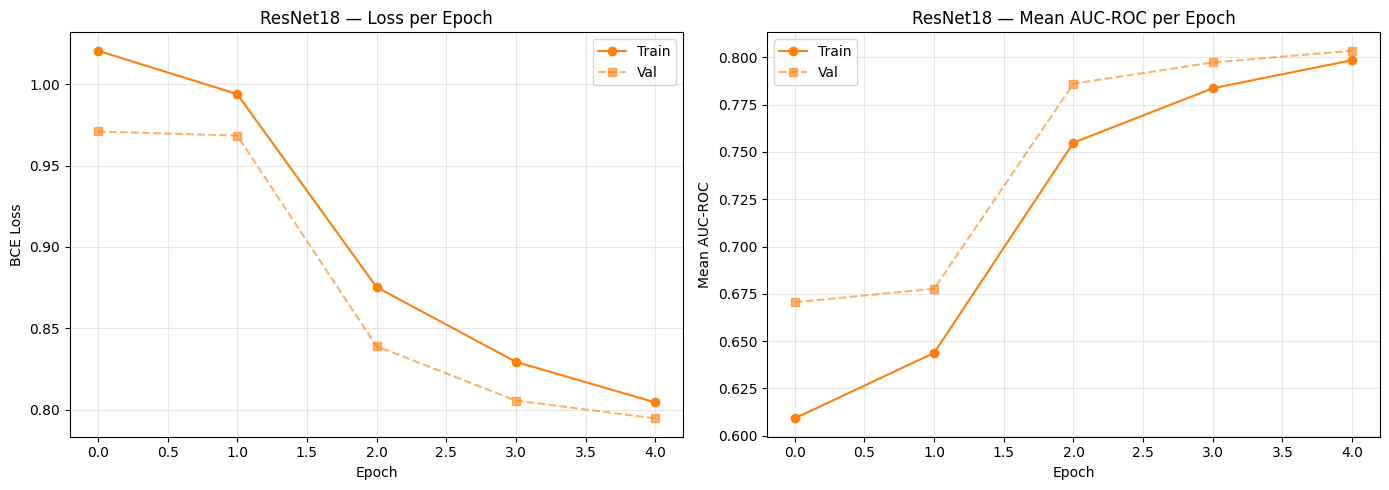

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(resnet_history['train_loss'], marker='o', label='Train', color='tab:orange')
axes[0].plot(resnet_history['val_loss'], marker='s', label='Val', color='tab:orange', alpha=0.6, linestyle='--')
axes[0].set_title('ResNet18 — Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(resnet_history['train_auc'], marker='o', label='Train', color='tab:orange')
axes[1].plot(resnet_history['val_auc'], marker='s', label='Val', color='tab:orange', alpha=0.6, linestyle='--')
axes[1].set_title('ResNet18 — Mean AUC-ROC per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean AUC-ROC')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'resnet18_loss_auc_curves.png'), dpi=150)
plt.show()

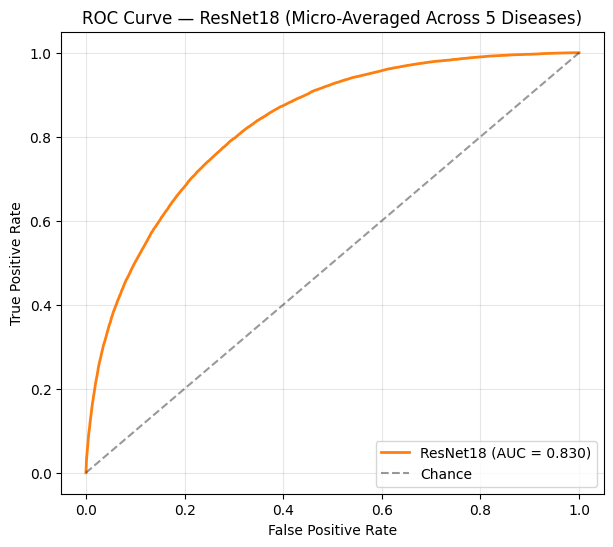

In [24]:
fpr, tpr, _ = roc_curve(resnet_test_labels.ravel(), resnet_test_preds.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ResNet18 (AUC = {roc_auc:.3f})', color='tab:orange', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — ResNet18 (Micro-Averaged Across 5 Diseases)')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'resnet18_roc.png'), dpi=150)
plt.show()

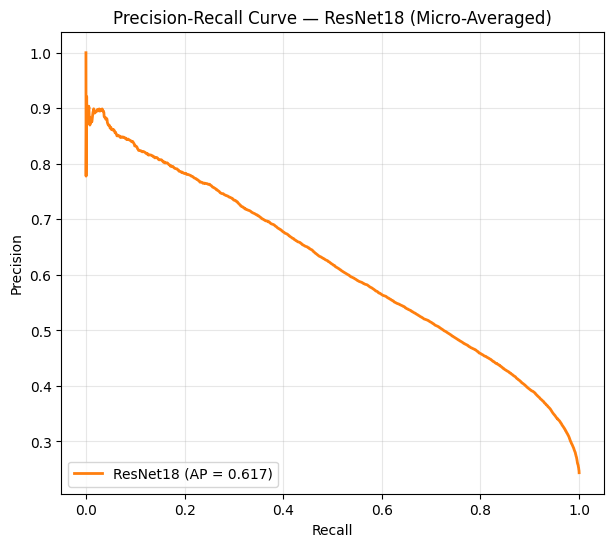

In [25]:
precision, recall, _ = precision_recall_curve(resnet_test_labels.ravel(), resnet_test_preds.ravel())
ap = average_precision_score(resnet_test_labels, resnet_test_preds, average='micro')

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f'ResNet18 (AP = {ap:.3f})', color='tab:orange', linewidth=2)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve — ResNet18 (Micro-Averaged)')
plt.legend(loc='lower left'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'resnet18_pr.png'), dpi=150)
plt.show()

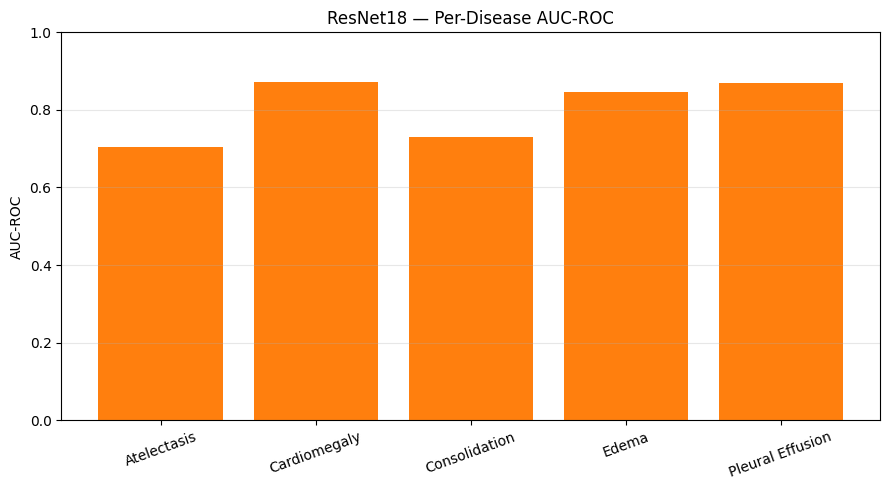

Atelectasis         : 0.7054
Cardiomegaly        : 0.8709
Consolidation       : 0.7302
Edema               : 0.8464
Pleural Effusion    : 0.8687


In [26]:
resnet_per_disease = _per_disease_auc(resnet_test_labels, resnet_test_preds)

plt.figure(figsize=(9, 5))
plt.bar(DISEASE_COLS, resnet_per_disease, color='tab:orange')
plt.ylabel('AUC-ROC'); plt.ylim(0, 1.0)
plt.title('ResNet18 — Per-Disease AUC-ROC')
plt.xticks(rotation=20)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'resnet18_per_disease_auc.png'), dpi=150)
plt.show()

for d, a in zip(DISEASE_COLS, resnet_per_disease):
    print(f"{d:20s}: {a:.4f}")

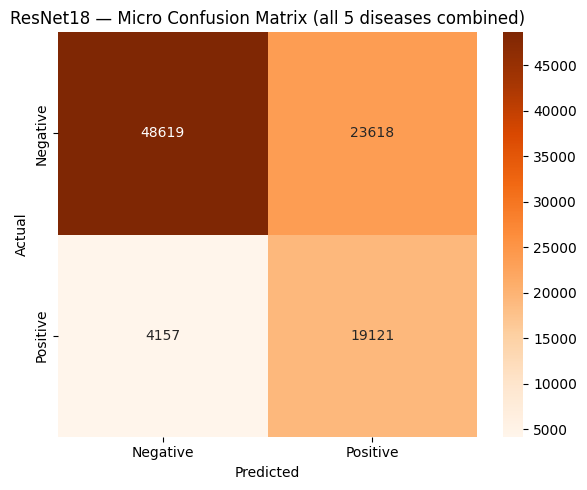

In [27]:
resnet_binary_preds = (resnet_test_preds >= 0.5).astype(int)
resnet_cm = confusion_matrix(resnet_test_labels.ravel(), resnet_binary_preds.ravel())

plt.figure(figsize=(6, 5))
sns.heatmap(resnet_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('ResNet18 — Micro Confusion Matrix (all 5 diseases combined)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'resnet18_confusion_matrix.png'), dpi=150)
plt.show()

## 12. Train Model 3 — CNN-LSTM

Note: noticeably slower per epoch than the other three (49 sequential CNN
passes per image at `patch_size=32` on a 224x224 image) — this is expected.


In [ ]:
cnnlstm_model = CNNLSTM(num_classes=len(DISEASE_COLS), img_size=IMG_SIZE)
cnnlstm_model, cnnlstm_history = train_model(cnnlstm_model, 'cnnlstm', freeze_schedule=False)

In [ ]:
with open(os.path.join(OUTPUT_DIR, 'cnnlstm_history.json'), 'w') as f:
    json.dump(cnnlstm_history, f)

In [ ]:
_, cnnlstm_test_auc, cnnlstm_test_labels, cnnlstm_test_preds = evaluate(cnnlstm_model, test_loader, criterion)
print(f"CNN-LSTM Test Mean AUC: {cnnlstm_test_auc:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(cnnlstm_history['train_loss'], marker='o', label='Train', color='tab:green')
axes[0].plot(cnnlstm_history['val_loss'], marker='s', label='Val', color='tab:green', alpha=0.6, linestyle='--')
axes[0].set_title('CNN-LSTM — Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(cnnlstm_history['train_auc'], marker='o', label='Train', color='tab:green')
axes[1].plot(cnnlstm_history['val_auc'], marker='s', label='Val', color='tab:green', alpha=0.6, linestyle='--')
axes[1].set_title('CNN-LSTM — Mean AUC-ROC per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean AUC-ROC')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cnnlstm_loss_auc_curves.png'), dpi=150)
plt.show()

In [ ]:
fpr, tpr, _ = roc_curve(cnnlstm_test_labels.ravel(), cnnlstm_test_preds.ravel())
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'CNN-LSTM (AUC = {roc_auc:.3f})', color='tab:green', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — CNN-LSTM (Micro-Averaged Across 5 Diseases)')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'cnnlstm_roc.png'), dpi=150)
plt.show()

In [ ]:
precision, recall, _ = precision_recall_curve(cnnlstm_test_labels.ravel(), cnnlstm_test_preds.ravel())
ap = average_precision_score(cnnlstm_test_labels, cnnlstm_test_preds, average='micro')
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f'CNN-LSTM (AP = {ap:.3f})', color='tab:green', linewidth=2)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve — CNN-LSTM (Micro-Averaged)')
plt.legend(loc='lower left'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'cnnlstm_pr.png'), dpi=150)
plt.show()

In [ ]:
cnnlstm_per_disease = _per_disease_auc(cnnlstm_test_labels, cnnlstm_test_preds)
plt.figure(figsize=(9, 5))
plt.bar(DISEASE_COLS, cnnlstm_per_disease, color='tab:green')
plt.ylabel('AUC-ROC'); plt.ylim(0, 1.0)
plt.title('CNN-LSTM — Per-Disease AUC-ROC')
plt.xticks(rotation=20); plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cnnlstm_per_disease_auc.png'), dpi=150)
plt.show()
for d, a in zip(DISEASE_COLS, cnnlstm_per_disease):
    print(f"{d:20s}: {a:.4f}")

In [ ]:
cnnlstm_binary_preds = (cnnlstm_test_preds >= 0.5).astype(int)
cnnlstm_cm = confusion_matrix(cnnlstm_test_labels.ravel(), cnnlstm_binary_preds.ravel())
plt.figure(figsize=(6, 5))
sns.heatmap(cnnlstm_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('CNN-LSTM — Micro Confusion Matrix (all 5 diseases combined)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cnnlstm_confusion_matrix.png'), dpi=150)
plt.show()

## 13. Train Model 4 — Vision Transformer (ViT-B/16)

In [ ]:
class ViTWrapper(nn.Module):
    def __init__(self, num_classes=5, dropout=0.3):
        super().__init__()
        self.backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        in_features = self.backbone.heads.head.in_features
        self.backbone.heads.head = nn.Identity()
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))

    def forward(self, x):
        return self.classifier(self.backbone(x))

vit_model = ViTWrapper(num_classes=len(DISEASE_COLS))
vit_model, vit_history = train_model(vit_model, 'vit', lr=5e-5, freeze_schedule=True)

In [ ]:
with open(os.path.join(OUTPUT_DIR, 'vit_history.json'), 'w') as f:
    json.dump(vit_history, f)

_, vit_test_auc, vit_test_labels, vit_test_preds = evaluate(vit_model, test_loader, criterion)
print(f"ViT Test Mean AUC: {vit_test_auc:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(vit_history['train_loss'], marker='o', label='Train', color='tab:red')
axes[0].plot(vit_history['val_loss'], marker='s', label='Val', color='tab:red', alpha=0.6, linestyle='--')
axes[0].set_title('ViT — Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(vit_history['train_auc'], marker='o', label='Train', color='tab:red')
axes[1].plot(vit_history['val_auc'], marker='s', label='Val', color='tab:red', alpha=0.6, linestyle='--')
axes[1].set_title('ViT — Mean AUC-ROC per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean AUC-ROC')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vit_loss_auc_curves.png'), dpi=150)
plt.show()

In [ ]:
fpr, tpr, _ = roc_curve(vit_test_labels.ravel(), vit_test_preds.ravel())
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ViT (AUC = {roc_auc:.3f})', color='tab:red', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — ViT (Micro-Averaged Across 5 Diseases)')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'vit_roc.png'), dpi=150)
plt.show()

In [ ]:
precision, recall, _ = precision_recall_curve(vit_test_labels.ravel(), vit_test_preds.ravel())
ap = average_precision_score(vit_test_labels, vit_test_preds, average='micro')
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f'ViT (AP = {ap:.3f})', color='tab:red', linewidth=2)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve — ViT (Micro-Averaged)')
plt.legend(loc='lower left'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'vit_pr.png'), dpi=150)
plt.show()

In [ ]:
vit_per_disease = _per_disease_auc(vit_test_labels, vit_test_preds)
plt.figure(figsize=(9, 5))
plt.bar(DISEASE_COLS, vit_per_disease, color='tab:red')
plt.ylabel('AUC-ROC'); plt.ylim(0, 1.0)
plt.title('ViT — Per-Disease AUC-ROC')
plt.xticks(rotation=20); plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vit_per_disease_auc.png'), dpi=150)
plt.show()
for d, a in zip(DISEASE_COLS, vit_per_disease):
    print(f"{d:20s}: {a:.4f}")

In [ ]:
vit_binary_preds = (vit_test_preds >= 0.5).astype(int)
vit_cm = confusion_matrix(vit_test_labels.ravel(), vit_binary_preds.ravel())
plt.figure(figsize=(6, 5))
sns.heatmap(vit_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('ViT — Micro Confusion Matrix (all 5 diseases combined)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vit_confusion_matrix.png'), dpi=150)
plt.show()

## 14. Final Test-Set Evaluation (all 4 models)

In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

_, mlp_auc, mlp_labels, mlp_preds = evaluate(mlp_model, test_loader, criterion)
_, resnet_auc, resnet_labels, resnet_preds = evaluate(resnet_model, test_loader, criterion)
_, cnnlstm_auc, cnnlstm_labels, cnnlstm_preds = evaluate(cnnlstm_model, test_loader, criterion)
_, vit_auc, vit_labels, vit_preds = evaluate(vit_model, test_loader, criterion)

test_labels = mlp_labels  # identical across models — same test_loader, same order

print(f"MLP       mean test AUC: {mlp_auc:.4f}")
print(f"ResNet18  mean test AUC: {resnet_auc:.4f}")
print(f"CNN-LSTM  mean test AUC: {cnnlstm_auc:.4f}")
print(f"ViT       mean test AUC: {vit_auc:.4f}")

## 15. Plot: Loss and AUC Curves (all 4 models, train + val)

In [ ]:
colors = {'MLP': 'tab:blue', 'ResNet18': 'tab:orange', 'CNN-LSTM': 'tab:green', 'ViT': 'tab:red'}
histories = {'MLP': mlp_history, 'ResNet18': resnet_history, 'CNN-LSTM': cnnlstm_history, 'ViT': vit_history}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, hist in histories.items():
    axes[0].plot(hist['train_loss'], marker='o', label=f'{name} (train)', color=colors[name])
    axes[0].plot(hist['val_loss'], marker='s', linestyle='--', label=f'{name} (val)', color=colors[name], alpha=0.6)
axes[0].set_title('Loss per Epoch — All Models')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for name, hist in histories.items():
    axes[1].plot(hist['train_auc'], marker='o', label=f'{name} (train)', color=colors[name])
    axes[1].plot(hist['val_auc'], marker='s', linestyle='--', label=f'{name} (val)', color=colors[name], alpha=0.6)
axes[1].set_title('Mean AUC-ROC per Epoch — All Models')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean AUC-ROC')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_auc_curves.png'), dpi=150)
plt.show()

## 16. Plot: ROC Curves (all 4 models, one graph)

Micro-averaged across all 5 diseases x all test samples — collapses each
model to a single representative curve, since a true per-disease-per-model
breakdown (5 x 4 = 20 lines) would be unreadable on one plot.


In [ ]:
model_preds = {'MLP': mlp_preds, 'ResNet18': resnet_preds, 'CNN-LSTM': cnnlstm_preds, 'ViT': vit_preds}

plt.figure(figsize=(9, 7))
for name, preds in model_preds.items():
    fpr, tpr, _ = roc_curve(test_labels.ravel(), preds.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', color=colors[name], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Micro-Averaged Across 5 Diseases) — Model Comparison')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_comparison.png'), dpi=150)
plt.show()

## 17. Plot: Precision-Recall Curves (all 4 models, one graph)

In [ ]:
plt.figure(figsize=(9, 7))
for name, preds in model_preds.items():
    precision, recall, _ = precision_recall_curve(test_labels.ravel(), preds.ravel())
    ap = average_precision_score(test_labels, preds, average='micro')
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.3f})', color=colors[name], linewidth=2)

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Micro-Averaged) — Model Comparison')
plt.legend(loc='lower left'); plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'pr_comparison.png'), dpi=150)
plt.show()

## 18. Per-Disease AUC-ROC Breakdown (all 4 models)

In [ ]:
per_disease_results = {}
for name, (labels, preds) in {
    'MLP': (mlp_labels, mlp_preds),
    'ResNet18': (resnet_labels, resnet_preds),
    'CNN-LSTM': (cnnlstm_labels, cnnlstm_preds),
    'ViT': (vit_labels, vit_preds),
}.items():
    per_disease_results[name] = _per_disease_auc(labels, preds)

per_disease_df = pd.DataFrame(per_disease_results, index=DISEASE_COLS)
print(per_disease_df.round(4))

fig, ax = plt.subplots(figsize=(11, 6))
per_disease_df.plot(kind='bar', ax=ax, rot=30)
ax.set_title('Per-Disease AUC-ROC — Model Comparison')
ax.set_ylabel('AUC-ROC'); ax.set_ylim(0, 1.0)
ax.legend(loc='lower right'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_disease_auc.png'), dpi=150)
plt.show()

## 19. Final Comparison Table (Accuracy-equivalent metrics at threshold 0.5)

In [ ]:
def multilabel_metrics(labels, preds, threshold=0.5):
    binary_preds = (preds >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, binary_preds, average='micro', zero_division=0
    )
    mean_auc = np.mean(_per_disease_auc(labels, preds))
    return mean_auc, precision, recall, f1

results = pd.DataFrame({
    'MLP':      multilabel_metrics(mlp_labels, mlp_preds),
    'ResNet18': multilabel_metrics(resnet_labels, resnet_preds),
    'CNN-LSTM': multilabel_metrics(cnnlstm_labels, cnnlstm_preds),
    'ViT':      multilabel_metrics(vit_labels, vit_preds),
}, index=['Mean AUC-ROC', 'Precision (micro)', 'Recall (micro)', 'F1 (micro)'])

print(results.round(4))
results.to_csv(os.path.join(OUTPUT_DIR, 'model_comparison.csv'))

fig, ax = plt.subplots(figsize=(11, 6))
results.T.plot(kind='bar', ax=ax, rot=0)
ax.set_title('Final Test Metrics — Model Comparison')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.legend(loc='lower right'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'metrics_comparison.png'), dpi=150)
plt.show()

## 20. Confusion Matrices

Multi-label doesn't have one natural confusion matrix per model (5 diseases x
2 classes each). We show a **flattened micro confusion matrix** per model
(treating every disease-label decision across every test image as one binary
classification instance) — the same micro-averaging principle used for the
ROC/PR curves above, applied consistently.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
model_data = {'MLP': (mlp_labels, mlp_preds), 'ResNet18': (resnet_labels, resnet_preds),
              'CNN-LSTM': (cnnlstm_labels, cnnlstm_preds), 'ViT': (vit_labels, vit_preds)}

for ax, (name, (labels, preds)) in zip(axes.flat, model_data.items()):
    binary_preds = (preds >= 0.5).astype(int)
    cm = confusion_matrix(labels.ravel(), binary_preds.ravel())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], ax=ax)
    ax.set_title(f'{name} — Micro Confusion Matrix (all diseases combined)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'), dpi=150)
plt.show()

print(f"\nAll outputs saved to: {OUTPUT_DIR}")